In [41]:
#!python -m pip install --upgrade pip
#%pip install pandas matplotlib seaborn scikit-learn openpyxl tensorflow xgboost aif360
#%pip install "aif360[Reductions, inFairness]"

In [42]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
from collections import Counter
from scipy.stats import chi2_contingency, fisher_exact

from fairlearn.metrics import MetricFrame
from fairlearn.metrics import demographic_parity_ratio, equalized_odds_ratio 
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, selection_rate, false_positive_rate, false_negative_rate, count
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

random_seed = 15

In [43]:
PATH = 'C:/Users/andre/Desktop/ProjectWork_AEQUITAS_AKKODIS/'

with open(PATH + 'data/predictions.json', 'r') as f:
    data = json.load(f)
predictions_df = pd.DataFrame(data['predictions'])
y_test = pd.Series(data['reference'])
s_test = pd.Series(data['sensitive'])
sensitive_features = data['sensitive_name']

s_test_dict = {feature: [row[i] for row in s_test] for i, feature in enumerate(sensitive_features)}

predictions_df.head(50)

,Logistic Regression,Linear Regression,Decision Tree,Naive Bayes,XGBoost,KNN,Neural Network,Logistic Regression_preprocessed_cr,Linear Regression_preprocessed_cr,Decision Tree_preprocessed_cr,...,KNN_preprocessed_cr,Neural Network_preprocessed_cr,Linear Regression_inprocessed_gfc,Logistic Regression_postprocessed_to,Linear Regression_postprocessed_to,Decision Tree_postprocessed_to,Naive Bayes_postprocessed_to,XGBoost_postprocessed_to,KNN_postprocessed_to,Neural Network_postprocessed_to
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,1,1,1,1,0,1,1,1,1,...,1,1,0,1,1,1,1,1,0,0
8,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
9,1,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,1,1,1,1,1


## Performance Metric

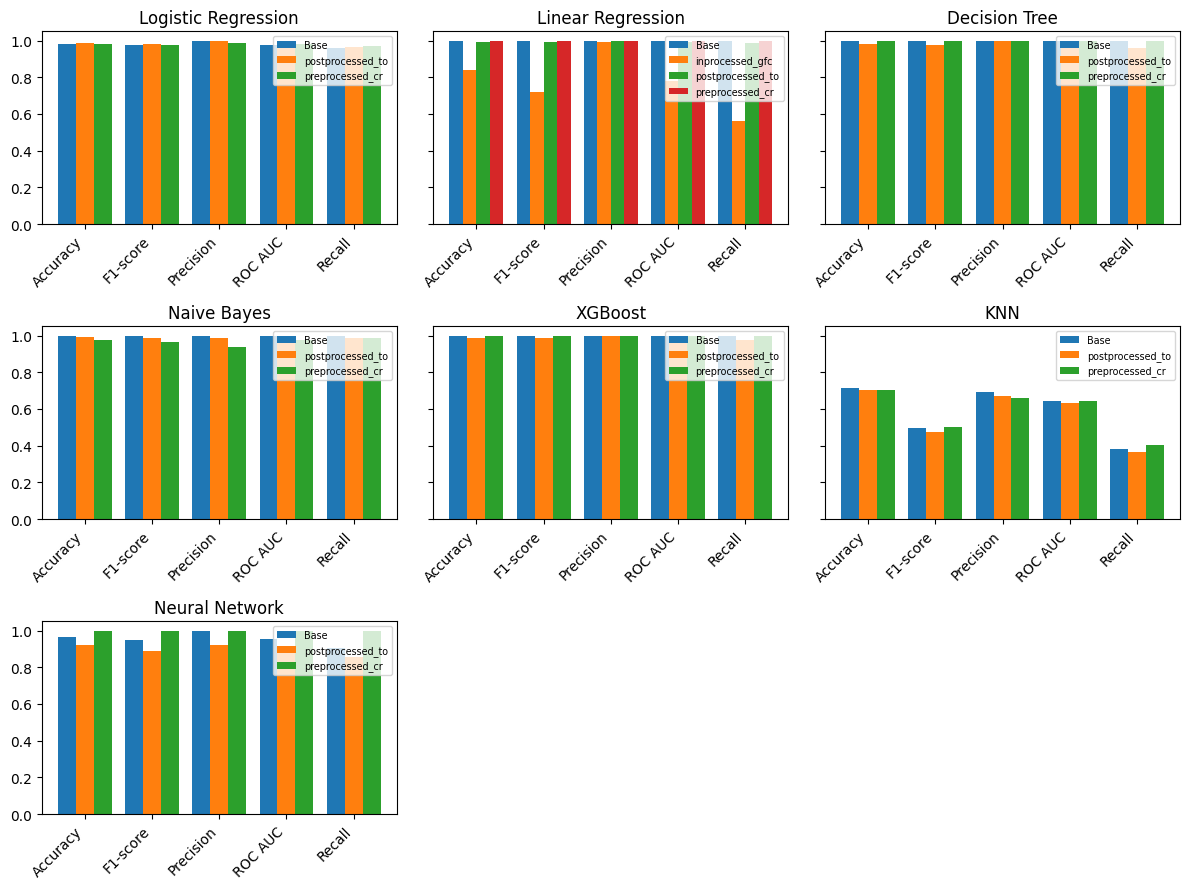

In [44]:
records = []
for name, y_pred in predictions_df.items():
    scores = {
        'Model':      name,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred),
        'Recall':     recall_score(y_test, y_pred),
        'F1-score':   f1_score(y_test, y_pred),
        'ROC AUC':    roc_auc_score(y_test, y_pred),
        'Group':      'Processed' if any(tag in name for tag in ['preprocessed','inprocessed','postprocessed'])
                      else 'Base'
    }
    records.append(scores)

df = pd.DataFrame(records).round(3)

df_long = df.melt(id_vars=['Model','Group'],
                  value_vars=['Accuracy','Precision','Recall','F1-score','ROC AUC'],
                  var_name='Metric',
                  value_name='Value')

base_models = df.loc[df.Group=='Base','Model'].unique()

ncols = 3
nrows = int(np.ceil(len(base_models)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), sharey=True)
axes = axes.flatten()

for ax, base in zip(axes, base_models):
    sel = df_long[df_long['Model'].str.startswith(base)]
    
    pivot = sel.pivot(index='Metric', columns='Model', values='Value')
    variants = pivot.columns.tolist()
    x = np.arange(len(pivot))
    width = 0.8 / len(variants)

    for i, var in enumerate(variants):
        label = var.replace(base + '_', '') if var != base else 'Base'
        ax.bar(x + (i - (len(variants)-1)/2)*width, pivot[var], width, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha='right')
    ax.set_title(base)
    ax.legend(fontsize='x-small')

for ax in axes[len(base_models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Fairness Metrics

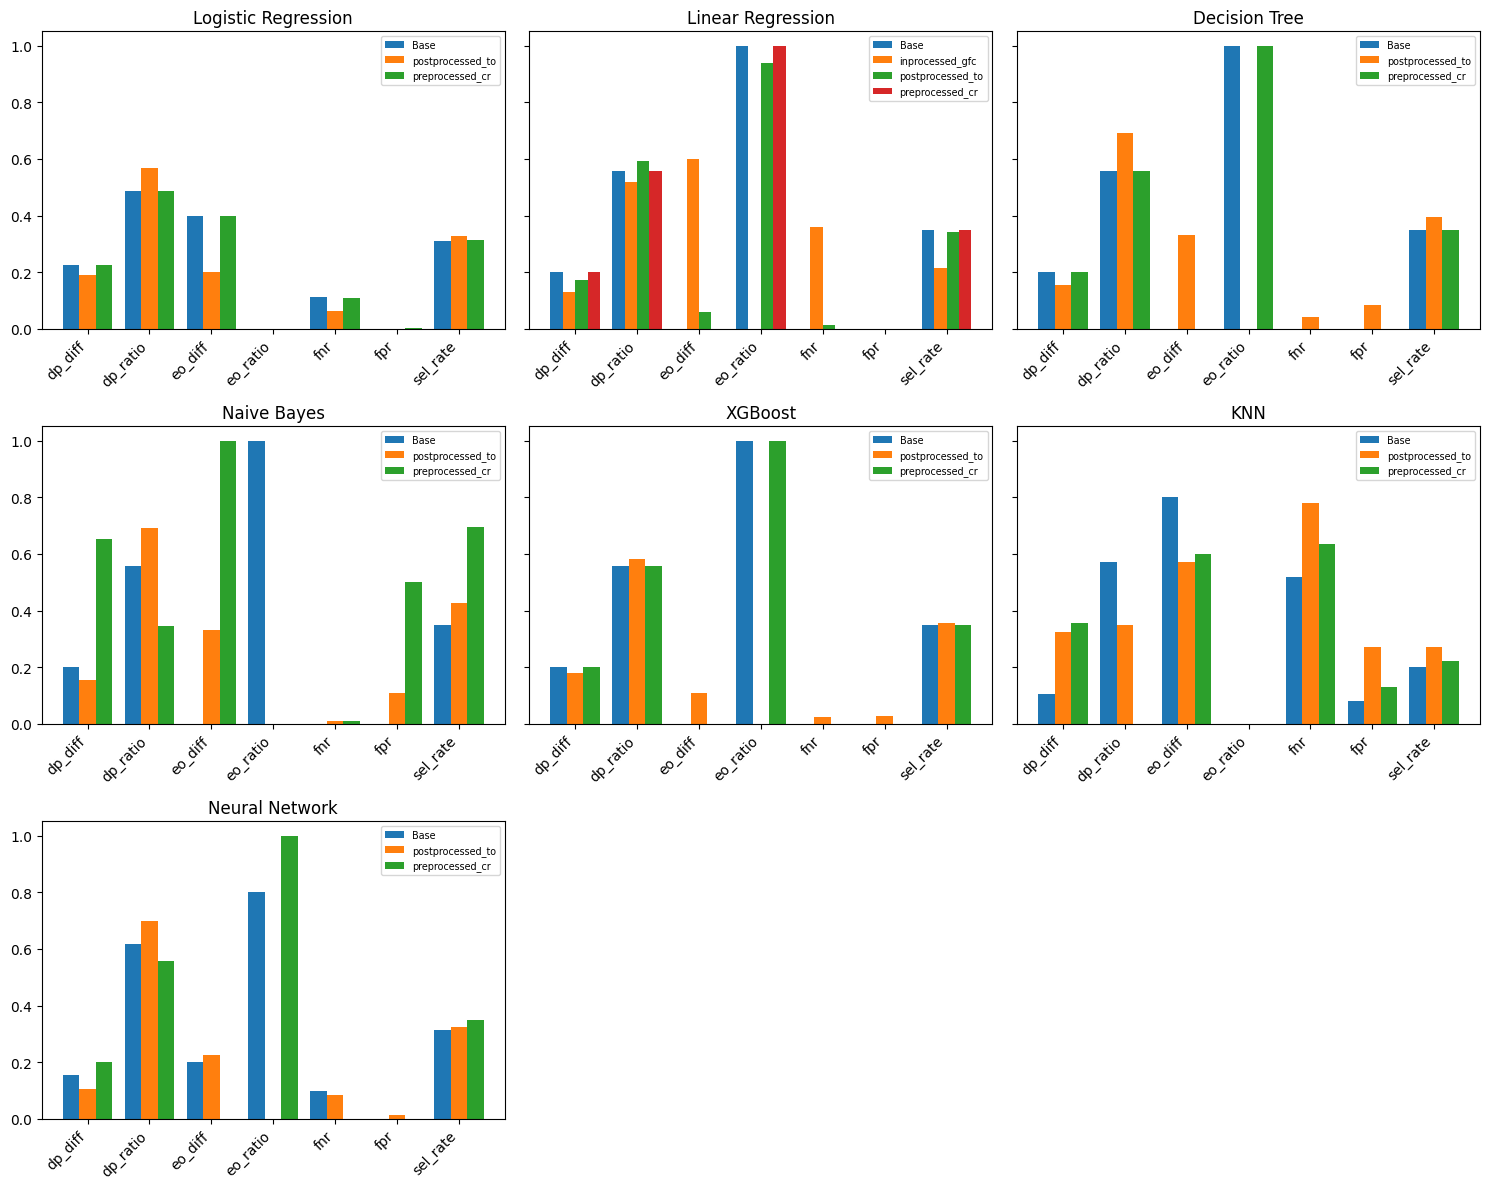

In [45]:
records = []
for name, y_pred in predictions_df.items():
    sf_df = pd.DataFrame(s_test.tolist(), columns=sensitive_features)
    mf = MetricFrame(
        metrics={
            'sel_rate': selection_rate,
            'fpr': false_positive_rate,
            'fnr': false_negative_rate,
            'count': count
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sf_df
    )
    dp_diff   = demographic_parity_difference(y_test, y_pred, sensitive_features=sf_df)
    eo_diff   = equalized_odds_difference(y_test, y_pred, sensitive_features=sf_df)
    dp_ratio  = demographic_parity_ratio(y_test, y_pred, sensitive_features=sf_df)
    eo_ratio  = equalized_odds_ratio(y_test, y_pred, sensitive_features=sf_df)

    for group_val, metrics in mf.by_group.iterrows():
        records.append({
            'Model':  name,
            'Group':  group_val,
            'Metric': 'sel_rate',
            'Value':  metrics['sel_rate']
        })
        records.append({
            'Model':  name,
            'Group':  group_val,
            'Metric': 'fpr',
            'Value':  metrics['fpr']
        })
        records.append({
            'Model':  name,
            'Group':  group_val,
            'Metric': 'fnr',
            'Value':  metrics['fnr']
        })
        records.append({
            'Model':  name,
            'Group':  group_val,
            'Metric': 'count',
            'Value':  metrics['count']
        })

    records.append({'Model': name, 'Group': 'OverallDiff',  'Metric': 'dp_diff',   'Value': dp_diff})
    records.append({'Model': name, 'Group': 'OverallDiff',  'Metric': 'eo_diff',   'Value': eo_diff})
    records.append({'Model': name, 'Group': 'OverallRatio', 'Metric': 'dp_ratio',  'Value': dp_ratio})
    records.append({'Model': name, 'Group': 'OverallRatio', 'Metric': 'eo_ratio',  'Value': eo_ratio})

fair_df = pd.DataFrame(records).round(3)

base_models = [
    m for m in predictions_df.columns
    if not any(tag in m for tag in ('preprocessed','inprocessed','postprocessed'))
]

ncols = 3
nrows = int(np.ceil(len(base_models) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4), sharey=True)
axes = axes.flatten()

metrics_to_plot = [
    'sel_rate', 'fpr', 'fnr',    # group‐level rates
    'dp_diff', 'eo_diff',        # overall differences
    'dp_ratio', 'eo_ratio'       # overall ratios
]

for ax, base in zip(axes, base_models):
    sel = fair_df[
        fair_df['Model'].str.startswith(base) &
        fair_df['Metric'].isin(metrics_to_plot)
    ]
    
    pivot = sel.pivot_table(index='Metric', columns='Model', values='Value')
    variants = pivot.columns.tolist()
    x = np.arange(len(pivot))
    width = 0.8 / len(variants)

    for i, var in enumerate(variants):
        label = var.replace(base + '_', '') if var != base else 'Base'
        ax.bar(x + (i - (len(variants) - 1) / 2) * width, pivot[var], width, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha='right')
    ax.set_title(base)
    ax.legend(fontsize='x-small')

for ax in axes[len(base_models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()
